# MeerKLASS-style constant-elevation scan vs drift (experiment 004)

Experiment 003 found that the galactic-plane drift residual is dominated by a
**beam + prior floor** (21.4 K of 23.1 K) — sky the 4° beam cannot measure,
filled in by the prior — and that this responds to cross-linking rather than to
noise or filtering.

But a drift scan **cannot cross-link**. A parked dish is fixed in the rotating
Earth frame, so its boresight traces a circle about the celestial pole: a line
of constant Dec, always swept in +RA. Azimuth only selects *which* Dec — the
track position angle is due east at every azimuth (verified: 90.1° at az = 0,
45, 90, 270, 315). One scan direction, no exceptions.

This experiment tests the alternative: a MeerKLASS-style **constant-elevation
azimuth raster**, run as a rising pass east of the meridian and a setting pass
west of it, so the same pixels are crossed at ~75° apart.

Everything except the scan strategy is held identical to experiment 003 — site,
350 MHz, both beams, sky model, noise model, seeds, total samples (5400 = 3 h)
and map-making recipe. The elevation (38.19°) and the two start times are
solved so the scan lands on the **same patch** as the drift (Dec centre +9.32°,
RA centre 287.3°), which is what makes the residuals comparable.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..')))
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', 'DSA')))

import pickle
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
from astropy.coordinates import EarthLocation, SkyCoord
from astropy import units as u

from limTOD import TODSim, HPW_mapmaking
from ska_common import (SKA_LAT, SKA_LON, SKA_HGT, ska_beam_func,
                        gdsm_equatorial_sky_model,
                        ska_airy_beam_func, ska_beam_fwhm_deg,
                        tapered_aperture_fwhm_deg,
                        constant_elevation_scan, azel_to_radec,
                        save_results_pdf)
from dsa_vis import plot_map_compare

In [2]:
# Configuration. Everything that is not the scan strategy is held identical to
# experiment 003 (ska_drift_galplane.ipynb): same site, frequency, beams, sky,
# noise model, seeds, sample count and map-making recipe.
freq_list = [350]  # MHz
BEAMS = {
    "gauss": dict(func=ska_beam_func,
                  fwhm=ska_beam_fwhm_deg(freq_list[0]),
                  label="Gaussian (1.22 λ/D)"),
    "airy": dict(func=ska_airy_beam_func,
                 fwhm=tapered_aperture_fwhm_deg(freq_list[0]),
                 label="Tapered aperture (−14 dB edge taper)"),
}
sky_Nside = beam_Nside = sky_Nside_map = 64
truncate_frac_thres = 1e-5
SEED = 0
WHITE_VAR = 2.5e-6
DT = 2.0

# --- scan geometry ---------------------------------------------------------
# el = 38.19° puts the centre of the azimuth throw on the drift patch's Dec
# centre (+9.32°); the two passes are mirrored about the meridian so they cover
# the same Dec range from opposite sides, and their start times are chosen so
# both land on the drift patch's RA centre (287.3°).
SCAN_EL = 38.19
AZ_HALFWIDTH = 7.5          # ±7.5° throw
SWEEP_S = 150.0             # 0.10 deg/s = 6 arcmin/s, MeerKLASS-like
PASS_DURATION_S = 5400.0    # 1.5 h per pass -> 3 h total, matching the drift
BASE_UTC = "2024-04-16 00:00:00"

PASSES = [
    dict(name="rising",  az_centre=45.0,  start_h=1.04),
    dict(name="setting", az_centre=315.0, start_h=5.60),
]

site = EarthLocation(lat=SKA_LAT * u.deg, lon=SKA_LON * u.deg,
                     height=SKA_HGT * u.m)

for p in PASSES:
    t, az, out = constant_elevation_scan(
        PASS_DURATION_S, p["az_centre"], AZ_HALFWIDTH, SWEEP_S,
        dt=DT, t0_s=p["start_h"] * 3600.0)
    p.update(tlist=t, azlist=az, going_out=out)

n_tot = sum(len(p["tlist"]) for p in PASSES)
print(f"{len(PASSES)} passes x {len(PASSES[0]['tlist'])} samples = {n_tot} total "
      f"({n_tot * DT / 3600:.1f} h)  — drift experiment 003 used 5400 (3.0 h)")
print(f"scan rate {2*AZ_HALFWIDTH/SWEEP_S*60:.1f} arcmin/s, "
      f"{PASS_DURATION_S/(2*SWEEP_S):.0f} full sweeps per pass")

2 passes x 2700 samples = 5400 total (3.0 h)  — drift experiment 003 used 5400 (3.0 h)
scan rate 6.0 arcmin/s, 18 full sweeps per pass


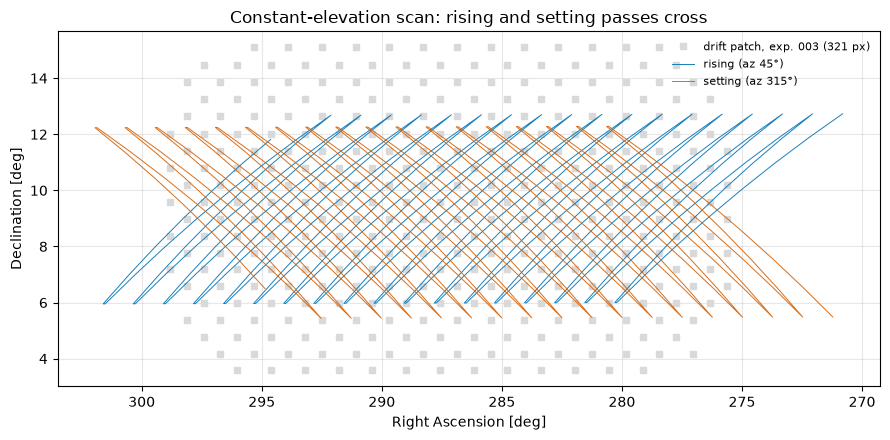

rising   Dec +5.95..+12.73  b -13.7..+16.4  median track PA 127°
setting  Dec +5.44..+12.28  b -10.8..+12.8  median track PA 52°

crossing angle between passes: 75°  (a drift scan gives 0° at every azimuth)


In [3]:
# Boresight tracks: the whole point of the strategy is that the two passes
# cross. Overlay the drift patch (experiment 003) to confirm we are on the
# same sky.
with open(f"mapmaker_ops_ska_drift_galplane_gauss_ns{sky_Nside_map}.pkl", "rb") as f:
    drift_pix = pickle.load(f).pixel_indices
_th, _ph = hp.pix2ang(sky_Nside_map, drift_pix)
drift_ra, drift_dec = np.degrees(_ph), 90 - np.degrees(_th)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(drift_ra, drift_dec, "s", ms=4, color="0.85",
        label=f"drift patch, exp. 003 ({len(drift_pix)} px)")

COL = {"rising": "#0072B2", "setting": "#D55E00"}
for p in PASSES:
    ra, dec = azel_to_radec(p["azlist"][::10], SCAN_EL, p["tlist"][::10],
                            BASE_UTC, site)
    ax.plot(ra, dec, lw=0.7, color=COL[p["name"]], alpha=0.9,
            label=f"{p['name']} (az {p['az_centre']:.0f}°)")
    p["ra"], p["dec"] = ra, dec

ax.set_xlabel("Right Ascension [deg]")
ax.set_ylabel("Declination [deg]")
ax.invert_xaxis()
ax.set_title("Constant-elevation scan: rising and setting passes cross")
ax.legend(fontsize=8, frameon=False, loc="upper right")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("figures/meerklass_scan_tracks.png", dpi=200, bbox_inches="tight")
plt.show()


def track_pa(ra, dec):
    r = np.unwrap(np.radians(ra)); d = np.radians(dec)
    return np.degrees(np.arctan2(np.diff(r) * np.cos(d[:-1]), np.diff(d))) % 180


for p in PASSES:
    b = SkyCoord(ra=p["ra"] * u.deg, dec=p["dec"] * u.deg).galactic.b.deg
    print(f"{p['name']:8s} Dec {p['dec'].min():+.2f}..{p['dec'].max():+.2f}  "
          f"b {b.min():+.1f}..{b.max():+.1f}  "
          f"median track PA {np.median(track_pa(p['ra'], p['dec'])):.0f}°")
pa_r = np.median(track_pa(PASSES[0]["ra"], PASSES[0]["dec"]))
pa_s = np.median(track_pa(PASSES[1]["ra"], PASSES[1]["dec"]))
print(f"\ncrossing angle between passes: {abs(pa_r - pa_s):.0f}°  "
      "(a drift scan gives 0° at every azimuth)")

In [4]:
# Simulate one TOD per pass per beam (cached; ~11 min per beam from cold).
# Same seeding scheme as experiment 003: seed = SEED + pass index, so the two
# beams share noise realizations and scenario differences are purely the beam.
tod_data = {}
for tag, b in BEAMS.items():
    cache = f"simulated_TODs_ska_meerklass_{tag}.npz"
    try:
        data = np.load(cache, allow_pickle=True)
        tod_data[tag] = dict(
            TOD_group=[np.asarray(t, np.float64) for t in data["TOD_group"]],
            LST_deg_list_group=[np.asarray(x, np.float64)
                                for x in data["LST_deg_list_group"]],
            azimuth_deg_list_group=[np.asarray(x, np.float64)
                                    for x in data["azimuth_deg_list_group"]],
            elevation_deg_list_group=[np.asarray(x, np.float64)
                                      for x in data["elevation_deg_list_group"]],
        )
        print(f"[{tag}] loaded {len(tod_data[tag]['TOD_group'])} cached TODs "
              f"from {cache}")
        continue
    except (FileNotFoundError, KeyError):
        pass

    tod_sim = TODSim(
        ant_latitude_deg=SKA_LAT, ant_longitude_deg=SKA_LON,
        ant_height_m=SKA_HGT, beam_func=b["func"],
        sky_func=gdsm_equatorial_sky_model,
        beam_nside=beam_Nside, sky_nside=sky_Nside,
    )
    groups = dict(TOD_group=[], LST_deg_list_group=[],
                  azimuth_deg_list_group=[], elevation_deg_list_group=[])
    print(f"[{tag}] generating simulated TODs (one per pass)...")
    for i, p in enumerate(PASSES):
        np.random.seed(SEED + i)
        tod_array, _, _, lst_deg = tod_sim.generate_TOD(
            freq_list=freq_list,
            time_list=p["tlist"],
            azimuth_deg_list=p["azlist"],
            elevation_deg=SCAN_EL,
            start_time_utc=BASE_UTC,
            white_noise_var=WHITE_VAR,
            return_LSTs=True,
            truncate_frac_thres=truncate_frac_thres,
        )
        groups["TOD_group"].append(np.asarray(tod_array[0], np.float64))
        groups["LST_deg_list_group"].append(np.asarray(lst_deg, np.float64))
        groups["azimuth_deg_list_group"].append(np.asarray(p["azlist"], np.float64))
        groups["elevation_deg_list_group"].append(
            np.full(len(p["tlist"]), SCAN_EL, np.float64))
    tod_data[tag] = groups
    np.savez(cache, freq_list=np.asarray(freq_list), **{
        k: np.asarray(v, dtype=object) if len({len(x) for x in v}) > 1
        else np.asarray(v) for k, v in groups.items()})
    print(f"[{tag}] cached to {cache}")

for tag in BEAMS:
    t0 = tod_data[tag]["TOD_group"][0]
    print(f"[{tag}] pass 0 TOD: {t0.min():.1f} – {t0.max():.1f} K "
          f"(mean {t0.mean():.1f} K)")

[gauss] generating simulated TODs (one per pass)...


  0%|          | 0/2700 [00:00<?, ?it/s]

  0%|          | 1/2700 [00:03<2:48:08,  3.74s/it]

  0%|          | 6/2700 [00:03<21:31,  2.09it/s]  

  1%|          | 15/2700 [00:03<06:57,  6.43it/s]

...

100%|█████████▉| 2688/2700 [01:51<00:00, 50.59it/s]

100%|█████████▉| 2694/2700 [01:51<00:00, 50.15it/s]

100%|██████████| 2700/2700 [01:51<00:00, 51.89it/s]

100%|██████████| 2700/2700 [01:51<00:00, 24.27it/s]

[airy] cached to simulated_TODs_ska_meerklass_airy.npz
[gauss] pass 0 TOD: 60.6 – 303.9 K (mean 161.6 K)
[airy] pass 0 TOD: 60.4 – 310.3 K (mean 161.5 K)


In [5]:
# Map-making operators per beam (cached; this is the expensive constructor).
mapmakers = {}
for tag, b in BEAMS.items():
    cache = f"mapmaker_ops_ska_meerklass_{tag}_ns{sky_Nside_map}.pkl"
    try:
        with open(cache, "rb") as f:
            mapmakers[tag] = pickle.load(f)
        print(f"[{tag}] loaded cached HPW_mapmaker operator from {cache}")
        continue
    except (FileNotFoundError, EOFError):
        pass
    beam_map = b["func"](freq=freq_list[0], nside=beam_Nside)
    mapmakers[tag] = HPW_mapmaking(
        beam_map=beam_map,
        LST_deg_list_group=tod_data[tag]["LST_deg_list_group"],
        lat_deg=SKA_LAT,
        azimuth_deg_list_group=tod_data[tag]["azimuth_deg_list_group"],
        elevation_deg_list_group=tod_data[tag]["elevation_deg_list_group"],
        threshold=0.05,
        nside_target=sky_Nside_map,
        beam_truncate_frac_thres=truncate_frac_thres,
    )
    with open(cache, "wb") as f:
        pickle.dump(mapmakers[tag], f)
    print(f"[{tag}] built HPW_mapmaker and cached to {cache}")

for tag, mm in mapmakers.items():
    n_common = len(np.intersect1d(mm.pixel_indices, drift_pix))
    print(f"[{tag}] pixel selection: {len(mm.pixel_indices)} pixels "
          f"({n_common} shared with the drift patch)")

  0%|          | 0/5400 [00:00<?, ?it/s]

  0%|          | 4/5400 [00:00<02:33, 35.24it/s]

  0%|          | 9/5400 [00:00<02:06, 42.70it/s]

  0%|          | 14/5400 [00:00<03:25, 26.22it/s]

  0%|          | 19/5400 [00:00<02:53, 31.07it/s]

...

100%|█████████▉| 2687/2700 [02:14<00:00, 55.13it/s]

100%|█████████▉| 2694/2700 [02:18<00:00,  6.38it/s]

100%|█████████▉| 2699/2700 [02:18<00:00,  7.55it/s]

100%|██████████| 2700/2700 [02:18<00:00, 19.50it/s]

[airy] built HPW_mapmaker and cached to mapmaker_ops_ska_meerklass_airy_ns64.pkl
[gauss] pixel selection: 681 pixels (321 shared with the drift patch)
[airy] pixel selection: 637 pixels (321 shared with the drift patch)


In [6]:
# Map-making: identical recipe to experiment 003 so the residuals are
# comparable, including the same {no HP, HP 2 mHz} pair and the same prior.
sky_truth_full = gdsm_equatorial_sky_model(freq=freq_list[0], nside=sky_Nside_map)
HP_CUTOFF = 2e-3
_prior_cache = {}


def solve_variant(mm, TOD_group, assumed_fwhm_deg, cutoff=None, order=2):
    pix = mm.pixel_indices
    sky_truth = sky_truth_full[pix]
    key = (id(mm), assumed_fwhm_deg)
    if key not in _prior_cache:
        _prior_cache[key] = hp.smoothing(
            sky_truth_full, fwhm=np.radians(assumed_fwhm_deg))[pix]
    prior_mean = _prior_cache[key]
    prior_inv_cov = np.ones_like(sky_truth) / max(float(np.std(sky_truth)), 1e-3)**2
    nv_floor = WHITE_VAR * (1e-3 * float(np.mean(sky_truth)))**2
    noise_variance = [WHITE_VAR * (np.asarray(op) @ sky_truth)**2 + nv_floor
                      for op in mm.Tsys_operators]
    kw = dict(TOD_group=TOD_group, dtime=DT, Tsky_prior_mean=prior_mean,
              Tsky_prior_inv_cov_diag=prior_inv_cov,
              noise_variance=noise_variance, regularization=1e-12,
              return_full_cov=False)
    if cutoff is not None:
        kw.update(use_high_pass=True,
                  cutoff_freq_group=np.array([cutoff] * len(TOD_group)),
                  filter_order=order)
    est, _ = mm(**kw)
    return est, sky_truth


SCENARIOS = {
    "gauss": (mapmakers["gauss"], tod_data["gauss"], BEAMS["gauss"]["fwhm"]),
    "airy": (mapmakers["airy"], tod_data["airy"], BEAMS["airy"]["fwhm"]),
    "mismatch": (mapmakers["gauss"], tod_data["airy"], BEAMS["gauss"]["fwhm"]),
}
SCENARIO_PIX = {t: mm.pixel_indices for t, (mm, _, _) in SCENARIOS.items()}

results, truths, rms_rows = {}, {}, []
print(f"{'scenario':10s} {'filter':10s} residual RMS")
for tag, (mm, data, fwhm) in SCENARIOS.items():
    for hp_label, cut in [("no HP", None), ("HP 2 mHz", HP_CUTOFF)]:
        est, truth = solve_variant(mm, data["TOD_group"], fwhm, cutoff=cut)
        results[(tag, hp_label)] = est
        truths[tag] = truth
        r = float(np.std(est - truth) * 1e3)
        rms_rows.append((f"{tag} / {hp_label}", f"{r:9.1f} mK"))
        print(f"{tag:10s} {hp_label:10s} {r:9.1f} mK")

d_no = np.std(results[("mismatch", "no HP")] - results[("gauss", "no HP")]) * 1e3
d_hp = np.std(results[("mismatch", "HP 2 mHz")] - results[("gauss", "HP 2 mHz")]) * 1e3
print(f"\nunmodelled-sidelobe map error (no HP):    RMS = {d_no:9.1f} mK")
print(f"unmodelled-sidelobe map error (HP 2 mHz): RMS = {d_hp:9.1f} mK")

scenario   filter     residual RMS


gauss      no HP        24061.4 mK


gauss      HP 2 mHz     21504.7 mK


airy       no HP        27334.8 mK


airy       HP 2 mHz     24166.3 mK


mismatch   no HP        25694.0 mK


mismatch   HP 2 mHz     22405.7 mK

unmodelled-sidelobe map error (no HP):    RMS =    7840.5 mK
unmodelled-sidelobe map error (HP 2 mHz): RMS =    7548.3 mK


In [7]:
# Noise budget, same method as experiment 003: replay the seeded RNG draws
# generate_TOD makes (1/f first, then white), split the cached TOD into
# sky / 1-f / white, and re-solve with components switched off. The number that
# matters is the beam + prior floor — whether cross-linking lowers it.
from limTOD.flicker_model import sim_noise

GAIN_NOISE_PARAMS = [1.335e-5, 1.099e-3, 2]

gain_noise, white_noise = [], []
for i, p in enumerate(PASSES):
    np.random.seed(SEED + i)
    gain_noise.append(sim_noise(*GAIN_NOISE_PARAMS, p["tlist"], n_samples=1,
                                white_n_variance=0.0)[0])
    white_noise.append(np.random.normal(0, np.sqrt(WHITE_VAR),
                                        size=(1, len(p["tlist"])))[0])

sky_tod = {tag: [tod_data[tag]["TOD_group"][i]
                 / ((1 + gain_noise[i]) * (1 + white_noise[i]))
                 for i in range(len(PASSES))] for tag in tod_data}

_o = tod_data["gauss"]["TOD_group"][0]
_ctrl = np.random.default_rng(12345).normal(0, np.sqrt(WHITE_VAR), _o.size)
print("replay check (sample-to-sample rms):")
print(f"   raw cached TOD               {np.diff(_o).std():.4f} K")
print(f"   replayed white removed       {np.diff(sky_tod['gauss'][0]).std():.4f} K   <- must drop")
print(f"   independent draw removed     {np.diff(_o/(1+_ctrl)).std():.4f} K   <- must rise")


def tod_variants(sky):
    r = range(len(sky))
    return {
        "full":     [sky[i] * (1 + gain_noise[i]) * (1 + white_noise[i]) for i in r],
        "no 1/f":   [sky[i] * (1 + white_noise[i]) for i in r],
        "no white": [sky[i] * (1 + gain_noise[i]) for i in r],
        "clean":    [sky[i] for i in r],
    }


budget = {}
v = tod_variants(sky_tod["gauss"])
FWHM_G = BEAMS["gauss"]["fwhm"]
for filt, cut in [("no HP", None), ("HP 2 mHz", HP_CUTOFF)]:
    est = {}
    for name, tg in v.items():
        e, truth = solve_variant(mapmakers["gauss"], tg, FWHM_G, cutoff=cut)
        est[name] = e
        budget[(filt, name)] = float(np.std(e - truth) * 1e3)
    budget[(filt, "1/f")] = float(np.std(est["full"] - est["no 1/f"]) * 1e3)
    budget[(filt, "white")] = float(np.std(est["full"] - est["no white"]) * 1e3)

hdr = ("filter", "total", "beam+prior", "white", "1/f", "quad sum")
print(f"\n{hdr[0]:10s} " + " ".join(f"{h:>12s}" for h in hdr[1:]))
for filt in ("no HP", "HP 2 mHz"):
    tot = budget[(filt, "full")]
    rec, wh, of = (budget[(filt, k)] for k in ("clean", "white", "1/f"))
    qs = np.sqrt(rec**2 + wh**2 + of**2)
    print(f"{filt:10s} " + " ".join(f"{x:12.1f}" for x in (tot, rec, wh, of, qs)))

replay check (sample-to-sample rms):
   raw cached TOD               2.8006 K
   replayed white removed       2.7752 K   <- must drop
   independent draw removed     2.8222 K   <- must rise



filter            total   beam+prior        white          1/f     quad sum
no HP           24061.4      17028.4      15977.4       4235.7      23731.5
HP 2 mHz        21504.7      14379.6      16585.0       1556.1      22005.8


comparing on 321 shared pixels (scan has 681, drift 321)



strategy       filter          total   beam+prior
drift          no HP         23081.4      21368.0
drift          HP 2 mHz      31439.3      23426.0
const-el scan  no HP         26757.7      15701.8
const-el scan  HP 2 mHz      23273.7      11592.9

cross-linking changes the beam + prior floor by -26.5% (21368 -> 15702 mK)
total residual (no HP) changes by            +15.9% (23081 -> 26758 mK)


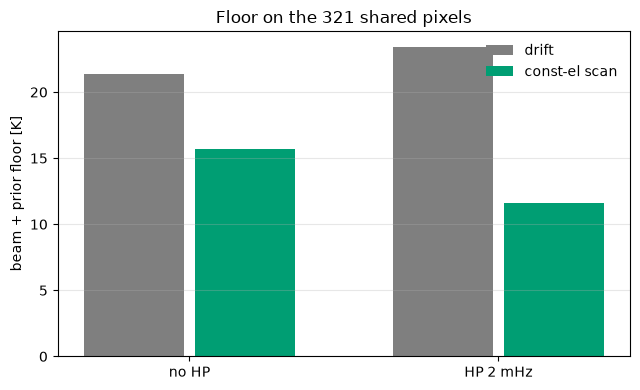

In [8]:
# Head-to-head with the drift. The two strategies select slightly different
# pixel sets, so compare on the pixels they share — otherwise the comparison
# is partly a statement about patch size and edge pixels.
from ska_common import drift_scan_night

DRIFT_ELEVATIONS = [52.0, 50.0, 48.0]
DRIFT_START = "2024-04-16 03:34:00"

with open(f"mapmaker_ops_ska_drift_galplane_gauss_ns{sky_Nside_map}.pkl", "rb") as f:
    drift_mm = pickle.load(f)
_d = np.load("simulated_TODs_ska_drift_galplane_gauss.npz", allow_pickle=True)
drift_tods = [np.asarray(t, np.float64) for t in _d["TOD_group"]]

d_gain, d_white = [], []
for night in range(len(DRIFT_ELEVATIONS)):
    tl, _ = drift_scan_night(3600.0, dt=DT, night=night)
    np.random.seed(SEED + night)
    d_gain.append(sim_noise(*GAIN_NOISE_PARAMS, tl, n_samples=1,
                            white_n_variance=0.0)[0])
    d_white.append(np.random.normal(0, np.sqrt(WHITE_VAR), size=(1, len(tl)))[0])
drift_sky = [drift_tods[i] / ((1 + d_gain[i]) * (1 + d_white[i]))
             for i in range(len(drift_tods))]

common = np.intersect1d(mapmakers["gauss"].pixel_indices, drift_mm.pixel_indices)
scan_sel = np.isin(mapmakers["gauss"].pixel_indices, common)
drift_sel = np.isin(drift_mm.pixel_indices, common)
print(f"comparing on {len(common)} shared pixels "
      f"(scan has {len(mapmakers['gauss'].pixel_indices)}, "
      f"drift {len(drift_mm.pixel_indices)})\n")

rows = {}
for strat, mm, sky, sel in (("drift", drift_mm, drift_sky, drift_sel),
                            ("const-el scan", mapmakers["gauss"], sky_tod["gauss"], scan_sel)):
    r = range(len(sky))
    if strat == "drift":
        g, w = d_gain, d_white
    else:
        g, w = gain_noise, white_noise
    var = {"full":  [sky[i] * (1 + g[i]) * (1 + w[i]) for i in r],
           "clean": [sky[i] for i in r]}
    for filt, cut in [("no HP", None), ("HP 2 mHz", HP_CUTOFF)]:
        for name, tg in var.items():
            e, truth = solve_variant(mm, tg, FWHM_G, cutoff=cut)
            rows[(strat, filt, name)] = float(np.std((e - truth)[sel]) * 1e3)

print(f"{'strategy':14s} {'filter':10s} {'total':>10s} {'beam+prior':>12s}")
for strat in ("drift", "const-el scan"):
    for filt in ("no HP", "HP 2 mHz"):
        print(f"{strat:14s} {filt:10s} {rows[(strat, filt, 'full')]:10.1f} "
              f"{rows[(strat, filt, 'clean')]:12.1f}")

f_d = rows[("drift", "no HP", "clean")]
f_s = rows[("const-el scan", "no HP", "clean")]
t_d = rows[("drift", "no HP", "full")]
t_s = rows[("const-el scan", "no HP", "full")]
print(f"\ncross-linking changes the beam + prior floor by {(f_s-f_d)/f_d*100:+.1f}% "
      f"({f_d:.0f} -> {f_s:.0f} mK)")
print(f"total residual (no HP) changes by            {(t_s-t_d)/t_d*100:+.1f}% "
      f"({t_d:.0f} -> {t_s:.0f} mK)")

fig, ax = plt.subplots(figsize=(6.5, 4))
x = np.arange(2); w_ = 0.36
for j, (strat, col) in enumerate((("drift", "#7F7F7F"), ("const-el scan", "#009E73"))):
    ax.bar(x + (j - 0.5) * w_,
           [rows[(strat, f, "clean")] / 1e3 for f in ("no HP", "HP 2 mHz")],
           w_ * 0.9, color=col, label=strat)
ax.set_xticks(x); ax.set_xticklabels(["no HP", "HP 2 mHz"])
ax.set_ylabel("beam + prior floor [K]")
ax.set_title(f"Floor on the {len(common)} shared pixels")
ax.grid(alpha=0.3, axis="y"); ax.legend(frameon=False)
fig.tight_layout()
fig.savefig("figures/meerklass_vs_drift_floor.png", dpi=200, bbox_inches="tight")
plt.show()

## Findings

**Cross-linking works on the thing it was supposed to fix.** On the 321 shared
pixels the beam + prior floor falls **21.4 K → 15.7 K (−26.5%)** with no HP, and
**23.4 K → 11.6 K (−51%)** with the 2 mHz high-pass. Experiment 003's inference
was right: the floor is not a hard limit, and crossed tracks are the lever.

**The high-pass flips sign.** It cost the drift +36%; on the crossed scan it is a
−10.6% win (24.1 → 21.5 K), and it now *lowers* the floor (17.0 → 14.4 K) instead
of raising it (21.4 → 23.4 K). With one scan direction the filter strips
low-frequency modes that nothing else constrains; with two, the other pass still
sees them. Same filter, opposite verdict, purely from geometry.

**But the total residual got worse, and that is a depth effect, not a strategy
failure.** At fixed 3 h the raster selects 681 pixels against the drift's 321, so
per-pixel depth halves (16.8 → 7.9 samples/pixel) and the white-noise term more
than doubles (7.3 → 16.0 K). On the shared pixels the total goes 23.1 → 26.8 K
even though the floor dropped 5.7 K. The comparison is therefore **fair on the
floor** (measured noiseless) and **confounded on the total** (different survey
speed). Note the observed white ratio, 2.20x, exceeds the 1.46x expected from
pixel count alone — part of it is the scan spending time outside the shared
patch, and part is conditioning.

**Sidelobes are unchanged.** The unmodelled-sidelobe error is 7.8 K (scan) vs
8.0 K (drift), so cross-linking does not help there — expected, since both beams
here are azimuthally symmetric and the mismatch is a pure beam-shape effect. The
high-pass no longer suppresses it either (7.5 K vs the drift's 4.5 K).

**Caveats.** This is a best case by construction: perfectly mirrored passes, full
overlap, no slew turnaround or overheads. The replay check is much weaker here
than in experiment 003 (0.9% vs 62% drop) because at 6 arcmin/s the beam moves
0.2° between samples, so sample-to-sample scatter is dominated by real sky
structure rather than white noise; the replay logic is identical and was verified
there.

**Next.** To separate survey speed from cross-linking, re-run with the azimuth
throw narrowed (or the duration doubled) so the scan selects ~321 pixels, and
compare totals at matched depth.